![alt text](68747470733a2f2f692e696d6775722e636f6d2f746249435378592e706e67.png)

In [1]:
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
from langchain_upstage import UpstageEmbeddings
from langchain_chroma import Chroma
from langchain_anthropic import ChatAnthropic
from langsmith import Client

embedding = UpstageEmbeddings(model="solar-embedding-1-large")

database = Chroma(
  collection_name= 'chroma-tax',
  persist_directory= './preprocessed-upstage',
  embedding_function= embedding     
)

retriever = database.as_retriever(
    search_type= 'mmr',
    search_kwargs={
        'k': 10,
        'fetch_k': 50,
        'lamda_mult': 0.6
    }
)


client = Client()

llm = ChatAnthropic(
    model= 'claude-sonnet-4-20250514',
    temperature= '0.1'
)

# claude-opus-4-5-20251101
# claude-sonnet-4-5-20250929
# claude-haiku-4-5-20251001

In [3]:
from typing_extensions import List, TypedDict
from langchain_core.documents import Document


class AgentState(TypedDict):
    query: str
    context: List
    answer: str

In [4]:
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
from typing import Literal



def retrieve(state: AgentState):
    query  = state['query']
    docs = retriever.invoke(query)
    return {'context': docs}

relevance_check_prompt = client.pull_prompt('langchain-ai/rag-document-relevance')

def doc_relevance_check_grader(state: AgentState) -> Literal['relevant', 'irrelevant']:
    context = state['context']
    query = state['query']
    doc_relevance_chain = relevance_check_prompt | llm
    response = doc_relevance_chain.invoke({'documents': context, 'question': query})

    if response['Score'] == 1:
        return 'relevant'
    
    return 'irrelevant'



rewrite_prompt = PromptTemplate.from_template("""
당신은 한국 세법 전문가입니다.
사용자의 질문을 소득세법 관련 웹 검색에 최적화된 형태로 다시 작성하세요.

규칙:
1. 일상 용어를 법률 용어로 변환 (예: 월급 → 근로소득)
2. 모호한 표현을 구체화
3. 검색에 필요한 핵심 키워드 포함

예시:
    소득 관련
    '월급, 급여 -> 근로소득',
    '집 팔 때 세금, 부동산 양도 -> 양도소득세',
    '이자, 배당 -> 금융소득',
    '프리랜서 수입, 외주 -> 사업소득',
    '강연료, 원고료 -> 기타소득',
    
    공제 관련
    '부양가족 공제 -> 인적공제',
    '카드 공제 -> 신용카드 소득공제',
    '의료비 공제 -> 의료비 세액공제',
    
    일반 표현
    '세금 돌려받기 -> 환급',
    '세금 신고 -> 확정신고',
    '직장인 연말 세금 -> 연말정산'

원본 질문: {query}
Retrieve 최적화된 질문:
""")

def rewrite(state: AgentState) -> AgentState:
    """
    사용자의 질문을 법률 용어에 적합하게 변경

    Args:
        state (AgentState): 사용자의 질문을 포함한 에이전트의 현재 state.

    Returns:
        AgentState: 변경된 질문을 포함하는 state를 반환
    """
    
    query = state['query']  # state에서 사용자의 질문 추출
    
    # rewrite 체인을 구성 프롬프트, LLM, 출력 파서 연결
    rewrite_chain = rewrite_prompt | llm | StrOutputParser()

    # query 변경
    response = rewrite_chain.invoke({'query': query})
    
    return {'query': response}  # 변경된 질문을 포함하는 state 반환



generate_prompt = client.pull_prompt("rlm/rag-prompt")

def generate(state: AgentState):
    context = state['context']
    query = state['query']
    rag_chain = generate_prompt | llm | StrOutputParser()
    response = rag_chain.invoke({'context': context, 'question': query})
    return {'answer': response}

In [5]:
from langchain_community.tools import TavilySearchResults

tavily_search_tool = TavilySearchResults(
    max_results=10,
    search_depth='advanced',
    include_answer=True,
    include_raw_content=True,
    include_images=False
    # include_domains=
    # exclude_domains=
    # name=
    # description=
    # args_schema=
)

def web_search(state: AgentState):
    """
    주어진 state를 기반으로 웹 검색을 수행합니다.

    Args:
        state (AgentState): 사용자의 질문을 포함한 에이전트의 현재 state.

    Returns:
        AgentState: 웹 검색 결과가 추가된 state를 반환합니다.
    """
    query = state['query']
    results = tavily_search_tool.invoke(query)
    
    return {'context': results}


basic_llm = ChatAnthropic(model="claude-haiku-4-5-20251001")

def basic_generate(state: AgentState) -> AgentState:
    """
    사용자의 질문에 기반하여 기본 답변을 생성합니다.

    Args:
        state (AgentState): 사용자의 질문을 포함한 에이전트의 현재 state.

    Returns:
        AgentState: 생성된 답변을 포함한 state를 반환합니다.
    """
    # state에서 질문을 추출합니다
    query = state['query']
    
    # 기본 LLM 체인을 생성합니다
    basic_llm_chain = basic_llm | StrOutputParser()
    
    # 체인을 사용하여 답변을 생성합니다
    llm_response = basic_llm_chain.invoke(query)
    
    # 생성된 답변을 'answer'로 반환합니다
    return {'answer': llm_response}

## router 모델

In [6]:
from langchain_core.prompts import ChatPromptTemplate
from pydantic import BaseModel, Field
from typing import Literal


class Route(BaseModel):         # JSON 스키마보단 간단하고, TypedDict 상속보단 명확히 지시할 수 있는 Pandatic BaseModel 상속
    target: Literal['vector_store', 'llm', 'web_search'] = Field(
        description="The target for the query to answer"
    )

router_system_prompt = """
You are an expert at routing a user's question to 'vector_store', 'llm', or 'web_search'.
'vector_store' contains information about income tax up to December 2025.
if you think the question is simple enough, use 'llm'
if you think you need to search the web to answer the question, use 'web_search'
"""


router_prompt = ChatPromptTemplate.from_messages([
    ('system', router_system_prompt),
    ('user', '{query}')
])

router_llm = ChatAnthropic(model="claude-haiku-4-5-20251001")
structured_router_llm = router_llm.with_structured_output(Route)

def router(state: AgentState) -> Literal['vector_store', 'llm', 'web_search']:
    """
    사용자의 질문에 기반하여 적절한 경로를 결정합니다.

    Args:
        state (AgentState): 사용자의 질문을 포함한 에이전트의 현재 state.

    Returns:
        Literal['vector_store', 'llm', 'web_search']: 질문을 처리하기 위한 적절한 경로를 나타내는 문자열.
    """
    # state에서 질문을 추출합니다
    query = state['query']
    
    # 프롬프트와 구조화된 라우터 LLM을 연결하여 체인을 생성합니다
    router_chain = router_prompt | structured_router_llm 
    
    # 체인을 사용하여 경로를 결정합니다
    route = router_chain.invoke({'query': query})

    # 결정된 경로의 타겟을 반환합니다
    return route.target

## Build 시작

In [ ]:
from langgraph.graph import StateGraph, START, END
from TaxSelfRag import self_rag_graph

graph_builder = StateGraph(AgentState)


graph_builder.add_node('generate', generate)
graph_builder.add_node('web_search', web_search)
graph_builder.add_node('basic_generate', basic_generate)
graph_builder.add_node('self_rag_graph', self_rag_graph)


graph_builder.add_conditional_edges(
    START,
    router,
    {
        'vector_store': 'self_rag_graph',
        'llm': 'basic_generate',
        'web_search': 'web_search'

    }
)

graph_builder.add_edge('web_search', 'generate')
graph_builder.add_edge('generate', END)

graph_builder.add_edge('basic_generate', END)

graph_builder.add_edge('self_rag_graph', END)


graph = graph_builder.compile()

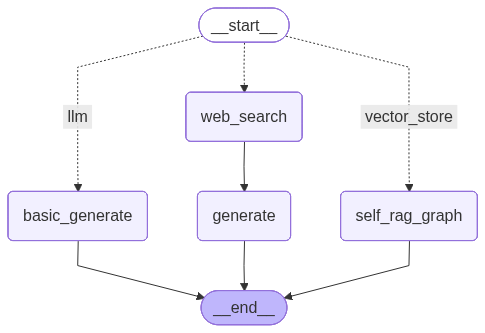

In [22]:
from IPython.display import display, Image

display(Image(graph.get_graph(xray=False).draw_mermaid_png()))

In [25]:
query='원천징수 대상 사업소득의 종류에 대해서 알려줘'
initial_state = {'query': query}
response = graph.invoke(initial_state)

In [ ]:
response['answer']  # self_rag 즉 agent node로 들어감

'원천징수 대상 사업소득은 대통령령으로 정하는 사업소득을 의미합니다. 제공된 문서에서는 구체적인 사업소득의 종류가 나열되어 있는데, 전문·과학·기술서비스업, 사업시설관리·사업지원·임대서비스업, 교육서비스업, 보건업·사회복지서비스업, 예술·스포츠·여가관련서비스업, 협회·단체·수리·기타개인서비스업, 가구내고용활동 등에서 발생하는 소득이 포함됩니다. 또한 복식부기의무자의 사업용 유형자산 양도소득과 이와 유사한 영리목적의 계속적·반복적 활동을 통한 소득도 원천징수 대상에 해당합니다.'

In [27]:
query='회기동 맛집 촨커에서 맛있는 메뉴 추천해줘'
initial_state = {'query': query}
response = graph.invoke(initial_state)

In [28]:
response['answer']

'회기동 맛집 촨커에서는 **꿔바로우**가 가장 추천되는 메뉴입니다. 바삭바삭한 튀김과 새콤달콤한 소스의 조합이 뛰어나며, 서울 3대 꿔바로우 맛집으로 불릴 정도로 유명합니다. **양꼬치**와 **지삼선**(감자와 가지를 튀겨 소스에 버무린 요리)도 함께 주문하면 더욱 맛있게 즐길 수 있습니다.'

In [ ]:
## 하고 싶은 것 ##

# 기능들을 최대한 잘게 쪼개고, 
# 이를 유동적으로 붙일 수 있는 orchestrator를 구현하는 것.
# Hallucination check랑 helpfulness check를 endpoint 직전에 위치시키고

# 답변 source를 vector store 혹은 웹 크롤링 을 할지를,
# 또 generate를 어떤 모델을 쓸 지를 routing 하고,
# 분리하기 힘든 기능들은 Agent로 구현해 node로 박는게 나을듯